# SignalDesk Workflow Health Check

**Track A: Fictional Domain Packet**

This notebook helps the SignalDesk product team identify which AI-assisted workflow appears healthiest and which result requires investigation before broader rollout.

The analysis prioritizes human-facing outcomes—completion, output acceptance, review flags, and user ratings—rather than treating model-reported confidence as proof of quality.

In [11]:
import pandas as pd

DATA_PATH = "sample-data/product_usage_events.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes
0,2026-08-01,Sales,Lead summary,email,42,35,29,3,8.5,0.74,4.1,normal day
1,2026-08-01,Sales,Lead summary,manual,18,12,8,2,6.0,0.61,3.8,normal day
2,2026-08-01,Support,Reply draft,queue,55,48,39,6,4.5,0.82,4.0,normal day
3,2026-08-01,Support,Reply draft,manual,11,8,5,1,3.0,0.68,NaN,missing rating
4,2026-08-01,Product,Feedback clustering,csv upload,12,9,6,2,14.0,0.59,3.6,small sample


## 1. Data Quality Review

Before calculating workflow metrics, I checked for missing values, inconsistent categories, duplicate export records, and contextual notes that could affect interpretation.

In [12]:
# Review missing values
print("Missing values:")
display(df.isna().sum().to_frame("missing_count"))

# Review categorical values for inconsistent spelling or casing
for column in ["team", "workflow", "source"]:
    print(f"\n{column}:")
    print(df[column].value_counts())

# Display rows with missing values or non-routine notes
issues = df[
    df.isna().any(axis=1)
    | ~df["notes"].isin(["normal day", "new prompt version started"])
]

display(issues)

Missing values:


,missing_count
date,0
team,0
workflow,0
source,0
sessions,0
completed,0
accepted_output,0
flagged_for_review,0
avg_minutes_saved,0
median_confidence,1



team:
team
Sales      14
Support    13
Product    13
product     1
Name: count, dtype: int64

workflow:
workflow
Lead summary           14
Feedback clustering    14
Reply draft            13
Name: count, dtype: int64

source:
source
manual        19
email          8
queue          7
csv upload     7
Name: count, dtype: int64


,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes
3,2026-08-01,Support,Reply draft,manual,11,8,5,1,3.0,0.68,NaN,missing rating
4,2026-08-01,Product,Feedback clustering,csv upload,12,9,6,2,14.0,0.59,3.6,small sample
5,2026-08-01,Product,Feedback clustering,manual,5,4,3,1,11.0,0.55,3.5,small sample
11,2026-08-02,product,Feedback clustering,manual,6,4,2,1,10.5,0.52,3.4,team casing differs
24,2026-08-05,Sales,Lead summary,email,140,126,119,2,12.0,0.95,4.9,traffic spike from demo account
25,2026-08-05,Sales,Lead summary,email,140,126,119,2,12.0,0.95,4.9,duplicate export row
30,2026-08-05,Product,Feedback clustering,manual,9,7,4,1,11.0,NaN,3.5,confidence missing as text
38,2026-08-07,Support,Reply draft,queue,30,17,8,12,1.5,0.91,2.1,review policy changed mid-day


## 2. Cleaning Decisions

I standardized the inconsistent team capitalization, converted the date column to a datetime type, and removed the row explicitly identified as a duplicate export.

I retained the demo-account traffic row because it represents a real recorded event, but I treat it as non-routine activity when interpreting results. Missing confidence and rating values remain missing rather than being imputed because there is not enough information to estimate them responsibly.

In [13]:
clean_df = df.copy()

# Standardize types and category casing
clean_df["date"] = pd.to_datetime(clean_df["date"])
clean_df["team"] = clean_df["team"].str.strip().str.title()

# Remove only the row explicitly identified as a duplicate export
clean_df = clean_df[
    clean_df["notes"].str.strip().str.lower() != "duplicate export row"
].copy()

print(f"Original rows: {len(df)}")
print(f"Rows after cleaning: {len(clean_df)}")
print(f"Rows removed: {len(df) - len(clean_df)}")

display(
    clean_df[
        clean_df["notes"].isin([
            "traffic spike from demo account",
            "confidence missing as text",
            "review policy changed mid-day"
        ])
    ]
)

Original rows: 41
Rows after cleaning: 40
Rows removed: 1


,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes
24,2026-08-05,Sales,Lead summary,email,140,126,119,2,12.0,0.95,4.9,traffic spike from demo account
30,2026-08-05,Product,Feedback clustering,manual,9,7,4,1,11.0,NaN,3.5,confidence missing as text
38,2026-08-07,Support,Reply draft,queue,30,17,8,12,1.5,0.91,2.1,review policy changed mid-day


## 3. Workflow Health Metrics

To avoid giving small rows the same influence as high-volume rows, rates are calculated from summed counts rather than by averaging row-level percentages.

- **Completion rate:** completed outputs divided by sessions
- **Overall acceptance rate:** accepted outputs divided by sessions
- **Acceptance among completed:** accepted outputs divided by completed outputs
- **Review flag rate:** flagged outputs divided by sessions

In [14]:
workflow_health = (
    clean_df.groupby("workflow")
    .agg(
        sessions=("sessions", "sum"),
        completed=("completed", "sum"),
        accepted_output=("accepted_output", "sum"),
        flagged_for_review=("flagged_for_review", "sum")
    )
)

workflow_health["completion_rate"] = (
    workflow_health["completed"] / workflow_health["sessions"]
)

workflow_health["overall_acceptance_rate"] = (
    workflow_health["accepted_output"] / workflow_health["sessions"]
)

workflow_health["acceptance_among_completed"] = (
    workflow_health["accepted_output"] / workflow_health["completed"]
)

workflow_health["review_flag_rate"] = (
    workflow_health["flagged_for_review"] / workflow_health["sessions"]
)

workflow_health = workflow_health.sort_values(
    "acceptance_among_completed",
    ascending=False
)

display(
    workflow_health.style.format({
        "completion_rate": "{:.1%}",
        "overall_acceptance_rate": "{:.1%}",
        "acceptance_among_completed": "{:.1%}",
        "review_flag_rate": "{:.1%}"
    })
)

,sessions,completed,accepted_output,flagged_for_review,completion_rate,overall_acceptance_rate,acceptance_among_completed,review_flag_rate
workflow,,,,,,,,
Lead summary,590,476,392,36,80.7%,66.4%,82.4%,6.1%
Reply draft,510,411,311,69,80.6%,61.0%,75.7%,13.5%
Feedback clustering,207,138,91,26,66.7%,44.0%,65.9%,12.6%


## 4. Human Outcomes vs. Model Confidence

Reply Draft is the highest-priority workflow to investigate because its model-reported confidence remained high while human-facing outcomes deteriorated. The queue source provides one consistent observation per day and isolates the August 7 policy-change event.

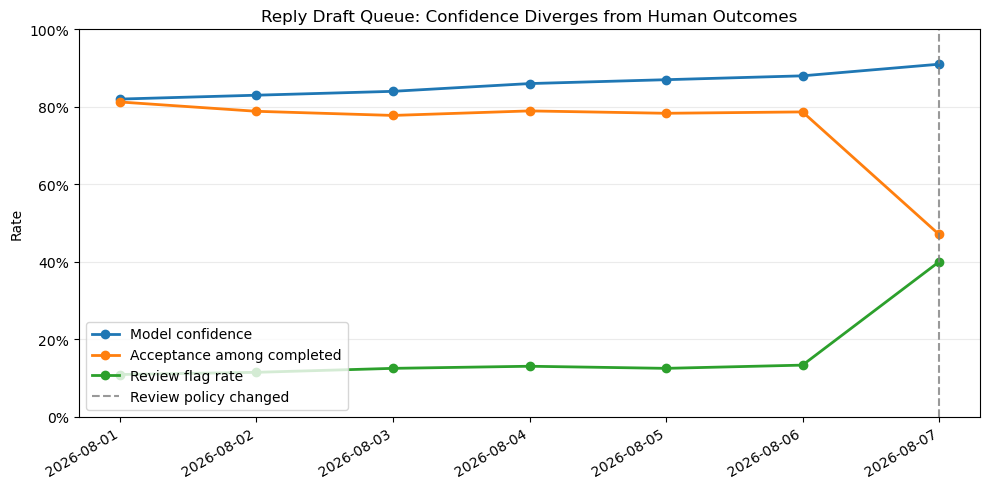

In [15]:
import matplotlib.pyplot as plt

reply_queue = (
    clean_df[
        (clean_df["workflow"] == "Reply draft")
        & (clean_df["source"] == "queue")
    ]
    .sort_values("date")
    .copy()
)

reply_queue["acceptance_among_completed"] = (
    reply_queue["accepted_output"] / reply_queue["completed"]
)

reply_queue["review_flag_rate"] = (
    reply_queue["flagged_for_review"] / reply_queue["sessions"]
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    reply_queue["date"],
    reply_queue["median_confidence"],
    marker="o",
    linewidth=2,
    label="Model confidence"
)

ax.plot(
    reply_queue["date"],
    reply_queue["acceptance_among_completed"],
    marker="o",
    linewidth=2,
    label="Acceptance among completed"
)

ax.plot(
    reply_queue["date"],
    reply_queue["review_flag_rate"],
    marker="o",
    linewidth=2,
    label="Review flag rate"
)

ax.axvline(
    pd.Timestamp("2026-08-07"),
    color="gray",
    linestyle="--",
    alpha=0.8,
    label="Review policy changed"
)

ax.set_title("Reply Draft Queue: Confidence Diverges from Human Outcomes")
ax.set_ylabel("Rate")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Interpretation

From August 1–6, Reply Draft queue acceptance remained near 75–81%, while review flags stayed near 11–13%. On August 7, model-reported confidence increased to 91%, but acceptance among completed outputs fell to 47.1% and the review flag rate rose to 40%.

This divergence makes model confidence the least trustworthy standalone health metric in this dataset. However, the review policy changed mid-day, so the data cannot establish that output quality itself declined. The policy change may have affected flagging behavior, and the aggregated daily row mixes pre-change and post-change activity.

**Next investigation:** separate August 7 activity into pre-policy and post-policy cohorts and manually audit a sample of flagged outputs.

## 5. Recommendation

**Lead Summary appears healthiest for continued use.** It has the highest acceptance among completed outputs (82.4%) and the lowest review flag rate (6.1%). However, its August 5 demo-account traffic should be excluded when estimating normal production performance.

**Reply Draft is the highest-priority investigation.** Its August 7 human-facing outcomes deteriorated while model confidence increased. Because the review policy changed mid-day, this is a signal for investigation—not proof that the model became worse.

**Feedback Clustering is not ready for a strong conclusion.** It has the lowest completion and acceptance rates, but it also has the smallest sample and the highest directional estimate of time saved.

### Recommended next steps

1. Split August 7 Reply Draft activity into pre-policy and post-policy cohorts.
2. Manually audit a sample of accepted and flagged Reply Draft outputs.
3. Exclude demo-account activity from routine production reporting.
4. Track completion, acceptance among completed outputs, review flags, and sample size weekly.
5. Treat confidence and estimated minutes saved as supporting context, not primary success measures.

### Limitation

This dataset contains only seven days of aggregated activity. It can identify operational signals and data-quality concerns, but it cannot establish causation or reliably predict future performance.